1. Load Dataset & Basic Understanding

In [1]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("/content/sample_data/Air_Quality.csv")

print(df.head())
print(df.info())
print(df.describe())


                        Date      City     CO   NO2  SO2    O3  PM2.5  PM10  \
0  2025-01-01 00:00:00+00:00  Brasilia  325.0  21.1  2.5  35.0   15.4  15.6   
1  2025-01-01 01:00:00+00:00  Brasilia  369.0  20.8  2.7  35.0   15.1  15.3   
2  2025-01-01 02:00:00+00:00  Brasilia  419.0  20.4  3.0  34.0   15.6  15.8   
3  2025-01-01 03:00:00+00:00  Brasilia  451.0  20.5  3.1  33.0   16.4  16.6   
4  2025-01-01 04:00:00+00:00  Brasilia  458.0  22.1  3.0  29.0   17.7  17.8   

         AQI  
0  20.483337  
1  20.425000  
2  20.333332  
3  20.258335  
4  20.316668  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52560 entries, 0 to 52559
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    52560 non-null  object 
 1   City    52560 non-null  object 
 2   CO      52560 non-null  float64
 3   NO2     52560 non-null  float64
 4   SO2     52560 non-null  float64
 5   O3      52560 non-null  float64
 6   PM2.5   52560 non-null  fl

In [2]:
print(df.isnull().sum())


Date     0
City     0
CO       0
NO2      0
SO2      0
O3       0
PM2.5    0
PM10     0
AQI      0
dtype: int64


In [4]:
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

2. Exploratory Data Analysis (EDA)

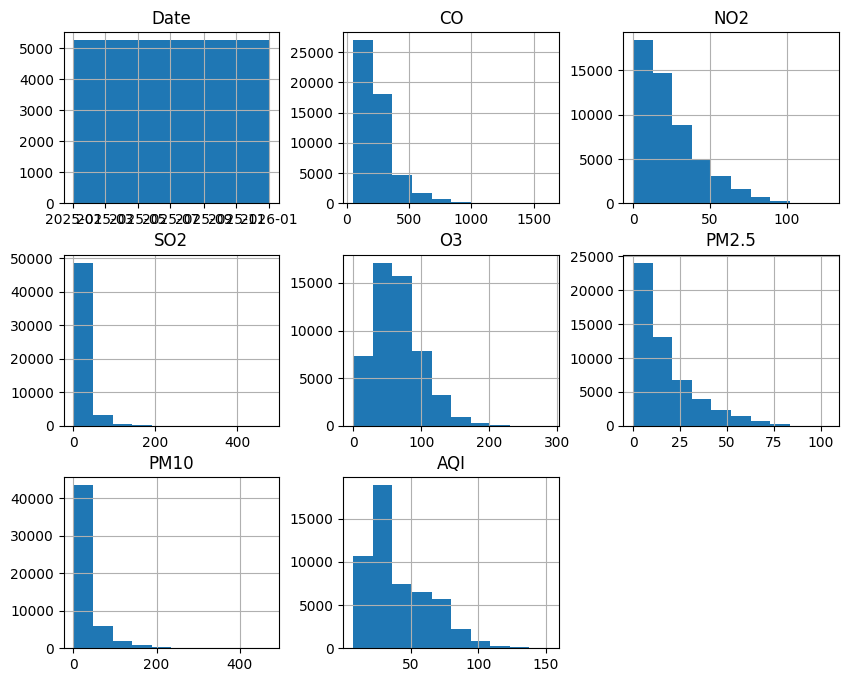

             CO       NO2       SO2        O3     PM2.5      PM10       AQI
CO     1.000000  0.617685  0.392683  0.002812  0.615434  0.432946  0.479892
NO2    0.617685  1.000000  0.467116 -0.424233  0.659447  0.430253  0.398633
SO2    0.392683  0.467116  1.000000 -0.028798  0.518649  0.373316  0.443628
O3     0.002812 -0.424233 -0.028798  1.000000  0.090535  0.183408  0.412755
PM2.5  0.615434  0.659447  0.518649  0.090535  1.000000  0.874455  0.808558
PM10   0.432946  0.430253  0.373316  0.183408  0.874455  1.000000  0.799229
AQI    0.479892  0.398633  0.443628  0.412755  0.808558  0.799229  1.000000


In [6]:
import matplotlib.pyplot as plt

# Convert 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'])

# Histogram of all features
df.hist(figsize=(10,8))
plt.show()

# Correlation matrix - select only numeric columns
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()
print(corr)

3. Prepare Data for Regression

In [9]:
X = df.drop(columns=['Date', 'City', 'AQI'])
y = df['AQI']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42)

4. Build Neural Network Regression Model

In [11]:
from keras.models import Sequential
from keras.layers import Dense
import numpy as np

model = Sequential()
model.add(Dense(64, activation='relu', input_dim=X_train.shape[1]))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))     # regression output

model.compile(optimizer='adam', loss='mse')

model.fit(X_train, y_train,
          epochs=20,
          batch_size=16,
          verbose=1)

# Evaluate
pred_nn = model.predict(X_test)

from sklearn.metrics import mean_squared_error, r2_score
rmse_nn = np.sqrt(mean_squared_error(y_test, pred_nn))
print("NN RMSE:", rmse_nn)
print("NN R2:", r2_score(y_test, pred_nn))

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2628/2628 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 127.7819
Epoch 2/20
2628/2628 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 90.6979
Epoch 3/20
2628/2628 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 88.5373
Epoch 4/20
2628/2628 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 92.3839
Epoch 5/20
2628/2628 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 88.6823
Epoch 6/20
2628/2628 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 86.6015
Epoch 7/20
2628/2628 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 84.4028
Epoch 8/20
2628/2628 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 85.6173
Epoch 9/20
2628/2628 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 83.3714
Epoch 10/20
2628/2628 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 80.2475
Epoch 11/20
2628/2628 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 81.5985
Epoch 12/20
2628/2628 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 80.6761
Epoch 13/20
2628/2628 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 79.7010
Epoch 14/20
2628/2628 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 78.3631
Epoch 15/20
2628/2628 ━━━

5. Two Classical ML Models

A. Linear Regression

In [15]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print("LR RMSE:",
      mean_squared_error(y_test, pred_lr))
print("LR R2:",
      r2_score(y_test, pred_lr))


LR RMSE: 104.13418974067626
LR R2: 0.7981576454851401


B. Random Forest Regressor

In [14]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("RF RMSE:",
      mean_squared_error(y_test, pred_rf))
print("RF R2:",
      r2_score(y_test, pred_rf))


RF RMSE: 51.68321245716601
RF R2: 0.8998228985386603


6. Hyperparameter Optimization (Cross Validation)

In [16]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10]
}

grid = GridSearchCV(RandomForestRegressor(),
                    params,
                    cv=3)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best CV Score:", grid.best_score_)


Best Params: {'max_depth': 10, 'n_estimators': 100}
Best CV Score: 0.8898330054798783


7. Feature Selection

In [17]:
from sklearn.feature_selection import SelectKBest, f_regression

selector = SelectKBest(score_func=f_regression, k=5)
X_new = selector.fit_transform(X, y)

print("Selected Features:", selector.get_support())


Selected Features: [ True False  True  True  True  True]


8. Final Model Comparison Table

In [19]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Neural Network"],
    "RMSE": [
        mean_squared_error(y_test, pred_lr),
        mean_squared_error(y_test, pred_rf),
        mean_squared_error(y_test, pred_nn)
    ],
    "R2": [
        r2_score(y_test, pred_lr),
        r2_score(y_test, pred_rf),
        r2_score(y_test, pred_nn)
    ]
})

print(results)


               Model        RMSE        R2
0  Linear Regression  104.134190  0.798158
1      Random Forest   51.683212  0.899823
2     Neural Network   81.668080  0.841704
